# GRIN Fiber Modal Optimization

Optimize the input spatial field profile (expressed in the fiber's guided-mode basis) so
that after propagating through a **highly multimoded GRIN fiber** the output intensity and
phase match a Gaussian target.  Physics: 2+1D nonlinear Schrödinger equation (x, y, z),
shot noise at ~1000× the quantum vacuum level, power fixed to 2× critical.

**Three optimization methods** are compared:
1. **Traditional NLO** — power-continuation Adam (linear → nonlinear regime)
2. **Direct Adam** — gradient descent with windowed checkpointing
3. **L-BFGS** — quasi-Newton via `scipy.optimize.minimize`


In [ ]:
# ── Hyperparameters ─────────────────────────────────────────────────────────
# Edit these before running; everything downstream derives from this cell.

# Grid
NX = NY = 256
LX = LY = 200e-6          # transverse domain size [m]  (6× core radius)

# Fiber
LAMBDA0  = 1064e-9        # central wavelength [m]
N_CORE   = 1.453          # core refractive index (silica at 1064 nm)
NA       = 0.10           # numerical aperture
R_CORE   = 25e-6          # core radius [m]
N2       = 2.76e-20       # nonlinear index [m²/W]

# Mode basis
N_MODES     = 45          # modes to include (≈ all guided modes for this fiber)
MODE_FOLDER = "grin_modes_256"

# Propagation
N_WINDOWS      = 10       # checkpointing windows (higher = less peak GPU RAM)
N_BEAT_LENGTHS = 25        # total propagation distance in units of L_beat

# Noise
SHOT_NOISE_FRAC = 1e-2   # dimensionless; noise amplitude at peak ≈ frac × I_peak^0.25 per √m

# Optimization (shared)
N_RESTARTS = 1            # independent random restarts per method (increase for statistics)
SEED       = 42
ADAM_LR    = 3e-2         # Adam learning rate

# Method 1 — Vellekoop-Mosk sequential phase scan + power continuation
N_POWER_LEVELS     = 5    # log-spaced power levels from 0.01 × P_cr to P_target
M_PHASES           = 10   # discrete phases scanned per mode: {0, 2π/M, ..., 2π(M-1)/M}
N_SWEEPS_PER_LEVEL = 1    # full passes through all N_MODES modes per power level

# Method 2 — direct Adam
N_STEPS_ADAM = 300

# Method 3 — L-BFGS
N_STEPS_LBFGS = 150       # max function evaluations

# Animation / output
N_SAVES_ANIM = 300         # z-snapshots for GIF
FPS_ANIM     = 20
FIG_DIR      = "figures"


In [ ]:
import os, sys, time, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from scipy.optimize import minimize

sys.path.insert(0, ".")
from gnlse_solver_noisy import (
    make_args, make_noise_samples, shot_noise_sigma,
    windowed_grad_noisy, windowed_forward_noisy, propagate_windowed,
    make_windowed_context_noisy, pml_optimal_Wmax,
)
from gnlse_source_prototype import solve_modes
from gnlse_medium import make_polynomial_n
from gnlse_visualizations_prototype import make_xy_z_animation, plot_modes_gallery

jax.config.update("jax_enable_x64", False)   # fp32 throughout (GPU memory)
os.makedirs(FIG_DIR, exist_ok=True)
print("JAX devices:", jax.devices())
print("NumPy:", np.__version__)


JAX devices: [CudaDevice(id=0)]
NumPy: 2.4.3


n_core=1.453  NA=0.1  n_clad=1.44955  Δ=0.00237
w₀ = 6.51 µm   L_beat = 1.141 mm
γ(bulk) = 1.630e-13 m/W   P_cr = 357535.22 W   P_target = 715070.44 W
ΔZ = 11.4 µm   Lz = 28.53 mm   steps = 2500
Grid: 512×512   dx = 0.39 µm


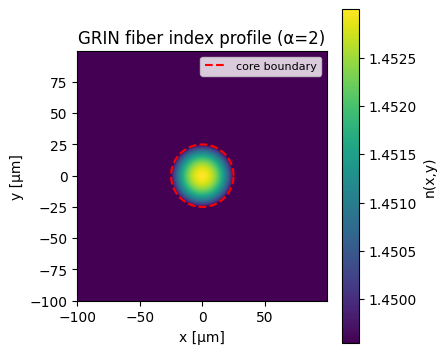

In [3]:
# ── Physical constants ───────────────────────────────────────────────────────
C0   = 2.99792458e8    # speed of light [m/s]
NT   = 1               # temporal bins: 1 → pure 2+1D spatial simulation
LT   = 1e-12           # dummy time window [s]

# ── Derived fiber quantities ─────────────────────────────────────────────────
n_clad  = float(np.sqrt(N_CORE**2 - NA**2))
Delta   = (N_CORE**2 - n_clad**2) / (2.0 * N_CORE**2)  # relative index difference
omega0  = 2.0 * np.pi * C0 / LAMBDA0

# Fundamental Gaussian mode waist in parabolic GRIN fiber
k0      = 2.0 * np.pi / LAMBDA0
w0      = float(np.sqrt(R_CORE / (k0 * N_CORE * np.sqrt(2.0 * Delta))))  # [m]

# Beat length = half-period of the 2D QHO (inter-mode spacing π/Δβ)
L_beat  = np.pi * R_CORE / np.sqrt(2.0 * Delta)          # [m]

# Critical power: L_NL = L_beat for the fundamental Gaussian mode
#   I_peak = 2P/(π w0²),  L_NL = 1 / (n2 ω0/c0 × I_peak)
#   P_cr   = π w0² / (2 × n2 × ω0/c0 × L_beat)
gamma   = N2 * omega0 / C0                                # bulk Kerr coefficient [m/W]
P_cr    = np.pi * w0**2 / (2.0 * gamma * L_beat)         # [W]
P_target = 2.0 * P_cr                                     # launch power

# Propagation grid
deltaZ      = L_beat / 100.0                               # step: 1/20 of beat length
Lz          = N_BEAT_LENGTHS * L_beat
steps_total = int(np.ceil(Lz / deltaZ))

# ── Spatial grid ─────────────────────────────────────────────────────────────
x  = np.linspace(-LX/2, LX/2, NX, endpoint=False)
y  = np.linspace(-LY/2, LY/2, NY, endpoint=False)
dx = float(x[1] - x[0])
dy = float(y[1] - y[0])
X, Y = np.meshgrid(x, y, indexing='ij')

# ── GRIN index profile: parabolic (α=2) ─────────────────────────────────────
n_xy = make_polynomial_n(X, Y, N_CORE, n_clad, R_CORE, alpha=2).astype(np.float32)

# ── Spatial PML ──────────────────────────────────────────────────────────────
PML_PIX  = 50
d_pml    = PML_PIX * dx
pml_Wmax = pml_optimal_Wmax(d_pml, target_db=40.0)

# ── GNLSE args (fp32, Nt=1, no temporal dispersion) ─────────────────────────
args = make_args(
    Nx=NX, Ny=NY, Nt=NT,
    Lx=LX, Ly=LY, Lt=LT, Lz=Lz,
    n_xyomega=n_xy,
    n_ref=N_CORE,
    n2_val=N2,
    lambda0=LAMBDA0,
    beta0_val=N_CORE * 2.0 * np.pi / LAMBDA0,
    beta1_val=N_CORE / C0,
    beta2_val=0.0,         # no temporal dispersion (2+1D)
    deltaZ=deltaZ,
    fr=0.0, sw=0,          # no Raman / self-steepening
    pml_thickness=PML_PIX,
    pml_Wmax=pml_Wmax,
    n_saves=N_SAVES_ANIM,
    precision='fp32',
)

print(f"n_core={N_CORE}  NA={NA}  n_clad={n_clad:.5f}  Δ={Delta:.5f}")
print(f"w₀ = {w0*1e6:.2f} µm   L_beat = {L_beat*1e3:.3f} mm")
print(f"γ(bulk) = {gamma:.3e} m/W   P_cr = {P_cr:.2f} W   P_target = {P_target:.2f} W")
print(f"ΔZ = {deltaZ*1e6:.1f} µm   Lz = {Lz*1e3:.2f} mm   steps = {steps_total}")
print(f"Grid: {NX}×{NY}   dx = {dx*1e6:.2f} µm")

# Visualise the refractive index profile
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(n_xy.T, origin='lower', extent=[x[0]*1e6, x[-1]*1e6,
                                                 y[0]*1e6, y[-1]*1e6],
               cmap='viridis')
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(R_CORE*1e6*np.cos(theta), R_CORE*1e6*np.sin(theta),
        'r--', lw=1.5, label='core boundary')
plt.colorbar(im, ax=ax, label='n(x,y)')
ax.set_xlabel('x [µm]'); ax.set_ylabel('y [µm]')
ax.set_title('GRIN fiber index profile (α=2)'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/grin_01_index.png', dpi=120)
plt.show()


In [4]:
# Solve fiber eigenmodes and cache to disk (skipped if folder already exists)
print(f"Solving up to {N_MODES} GRIN modes on {NX}×{NY} grid …")
t0 = time.time()
_ = solve_modes(
    n_xy.astype(np.float64),   # eigensolver needs float64
    n_ref=N_CORE,
    x=x, y=y,
    lambda0=LAMBDA0,
    n_modes=N_MODES,
    folder=MODE_FOLDER,
    overwrite=False,
)
print(f"Done in {time.time()-t0:.1f} s  (folder: {MODE_FOLDER})")


Solving up to 45 GRIN modes on 512×512 grid …
Folder already exists with 45 mode(s): grin_modes_256
  Use overwrite=True to recompute.
Done in 0.0 s  (folder: grin_modes_256)


/home/jsferran/miniconda3/envs/WMCO_env/lib/python3.14/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


Mode matrix B: (262144, 45)  (NX×NY, N_MODES)
β range: 8577572.064282 … 8559654.737853 rad/m

Overlap ‖〈φᵢ|φⱼ〉‖  (first 4 modes, should be ≈ I):
[[1.     0.     0.     0.    ]
 [0.     1.     0.2903 0.    ]
 [0.     0.2903 1.     0.    ]
 [0.     0.     0.     1.    ]]


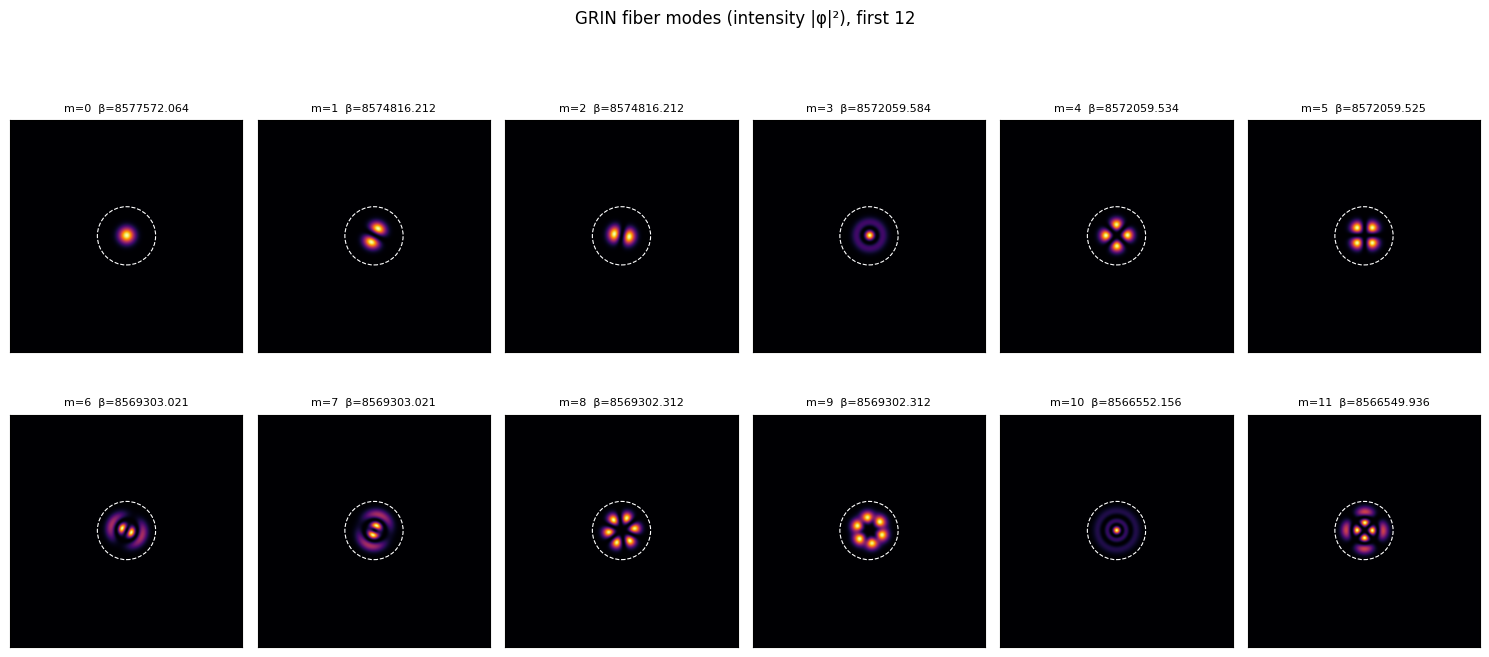

In [5]:
# ── Load modes → build matrix B ──────────────────────────────────────────────
# B[:, m] = φ_m(x,y).ravel(),  L²-normalised: Σ|φ_m|² dx dy = 1
B      = np.zeros((NX * NY, N_MODES), dtype=np.complex64)
betas  = np.zeros(N_MODES)
mfolder = Path(MODE_FOLDER)
for m in range(N_MODES):
    data      = np.load(mfolder / f"mode_{m:04d}.npz")
    B[:, m]   = data['field'].ravel().astype(np.complex64)
    betas[m]  = float(data['beta'])

# Precompute B on JAX device for GPU-accelerated projection
B_jax = jnp.asarray(B)

print(f"Mode matrix B: {B.shape}  (NX×NY, N_MODES)")
print(f"β range: {betas[0]:.6f} … {betas[-1]:.6f} rad/m")

# Orthogonality check (first 4 modes)
OL = B[:, :4].conj().T @ B[:, :4] * dx * dy
print("\nOverlap ‖〈φᵢ|φⱼ〉‖  (first 4 modes, should be ≈ I):")
print(np.round(np.abs(OL), 4))

# ── Mode gallery ─────────────────────────────────────────────────────────────
n_show = min(12, N_MODES)
n_cols = 6
n_rows = (n_show + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.5 * n_rows))
axes = np.asarray(axes).ravel()
core_circle = plt.Circle((0, 0), R_CORE*1e6, fill=False, color='white',
                          linestyle='--', linewidth=0.8)
for m in range(n_show):
    phi = B[:, m].reshape(NX, NY)
    ax  = axes[m]
    ax.imshow(np.abs(phi).T**2, origin='lower', cmap='inferno',
              extent=[x[0]*1e6, x[-1]*1e6, y[0]*1e6, y[-1]*1e6])
    ax.add_patch(plt.Circle((0,0), R_CORE*1e6, fill=False,
                            color='white', linestyle='--', linewidth=0.8))
    ax.set_title(f'm={m}  β={betas[m]:.3f}', fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
for ax in axes[n_show:]: ax.set_visible(False)
fig.suptitle(f'GRIN fiber modes (intensity |φ|²), first {n_show}', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/grin_02_modes.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
# Pre-compile the noisy propagator (takes ~30 s first time, subsequent calls are fast)
print("Compiling shot-noise propagator …")
t0 = time.time()
ctx = make_windowed_context_noisy(args, NT, use_shot_noise=True)
jnp.zeros(1).block_until_ready()
print(f"Compiled in {time.time()-t0:.1f} s")

# Compile a backward-safe context with use_shot_noise=False.
# When use_shot_noise=True, the VJP differentiates through sigma(A) = frac*|A|^q,
# producing d(sigma)/dA ∝ |A|^(q-1) gradient terms that diverge near zero → NaN
# in Adam and L-BFGS. This context passes sigma as a fixed scalar → stable VJP.
print("Compiling backward-safe (no-shot-noise) context …")
t0 = time.time()
ctx_clean = make_windowed_context_noisy(args, NT, use_shot_noise=False)
jnp.zeros(1).block_until_ready()
print(f"Backward context compiled in {time.time()-t0:.1f} s")

# ── Helper: k-space checkpoints → real-space animation array ─────────────────
def checkpoints_to_field4d(checkpoints):
    """Convert list of k-space checkpoints to (NX, NY, NT, N_ckpts) real-space array."""
    n_ckpts = len(checkpoints) - 1   # skip initial state
    buf = np.zeros((NX, NY, NT, n_ckpts), dtype=np.complex64)
    for i in range(n_ckpts):
        kwo = np.asarray(checkpoints[i + 1])
        xyt = np.fft.ifftn(kwo, axes=(0, 1, 2))
        buf[..., i] = xyt.astype(np.complex64)
    return buf

# ── Speckle initial field ─────────────────────────────────────────────────────
rng = np.random.default_rng(SEED)
c_sp = rng.standard_normal(N_MODES) + 1j * rng.standard_normal(N_MODES)
f_sp = B @ c_sp.astype(np.complex64)
f_sp = f_sp * np.sqrt(P_target / (np.sum(np.abs(f_sp)**2) * dx * dy))
A0_speckle = f_sp.reshape(NX, NY, NT)

sigma_shot = shot_noise_sigma(A0_speckle, SHOT_NOISE_FRAC)
print(f"Speckle P = {np.sum(np.abs(A0_speckle)**2)*dx*dy:.2f} W")
print(f"Shot-noise sigma = {sigma_shot:.3e}")

# Sample noise and propagate
key_sp = jax.random.PRNGKey(SEED + 100)
eps_sp = make_noise_samples(key_sp, steps_total, NX, NY, NT, dtype=jnp.complex64)

t0 = time.time()
fwd_sp = windowed_forward_noisy(
    args, A0_speckle, eps_sp, sigma_shot,
    use_shot_noise=True, n_windows=N_WINDOWS, ctx=ctx,
)
print(f"Speckle propagation: {time.time()-t0:.1f} s")

field4d_sp = checkpoints_to_field4d(fwd_sp['checkpoints'])
z_sp = np.linspace(0, Lz, field4d_sp.shape[-1] + 1)[1:]

fname_sp = f'{FIG_DIR}/grin_speckle_propagation.gif'
make_xy_z_animation(
    field4d_sp, t_index=0,
    x=x*1e6, y=y*1e6, z=z_sp*1e3,
    quantity='intensity', norm='per_frame',
    fps=FPS_ANIM, filename=fname_sp, dpi=100,
)
print(f"Speckle animation saved → {fname_sp}")

# Static snapshot at input and output
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, snap, title in zip(axes,
                            [A0_speckle[:, :, 0], field4d_sp[:, :, 0, -1]],
                            ['Input speckle', 'Output after propagation']):
    im = ax.imshow(np.abs(snap).T**2, origin='lower', cmap='inferno',
                   extent=[x[0]*1e6, x[-1]*1e6, y[0]*1e6, y[-1]*1e6])
    ax.add_patch(plt.Circle((0,0), R_CORE*1e6, fill=False,
                            color='cyan', linestyle='--', linewidth=1.2))
    ax.set_xlabel('x [µm]'); ax.set_ylabel('y [µm]')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='|A|² [W/m²]')
fig.suptitle(f'Speckle propagation (P = {P_target:.1f} W, shot noise σ_frac={SHOT_NOISE_FRAC})')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/grin_03_speckle.png', dpi=120)
plt.show()

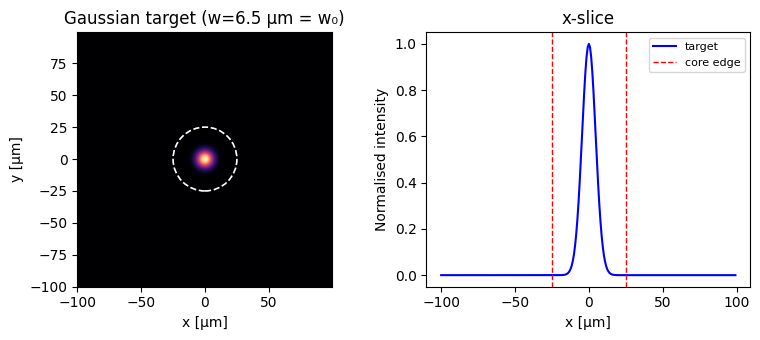

Target Gaussian waist: 6.51 µm  (w₀ = 6.51 µm)


In [ ]:
# ── Target: Gaussian matching the fundamental GRIN mode waist ────────────────
# Using w_target = w0 (mode-field radius of LP₀₁).
# The loss is a coherent fidelity: L = 1 − |〈G|A_out〉|² / (‖G‖² ‖A_out‖²)
# Evaluated in k-space for efficiency (Parseval: inner products are invariant).

W_TARGET = w0    # Gaussian waist [m]; change to explore other targets

G_xy  = np.exp(-(X**2 + Y**2) / W_TARGET**2).astype(np.float32)
G_xyt = G_xy[:, :, np.newaxis]   # (NX, NY, 1)

# k-space target (fixed constant in loss_fn)
G_kwo_np  = np.fft.fftn(G_xyt, axes=(0, 1, 2)).astype(np.complex64)
G_kwo_jax = jnp.asarray(G_kwo_np)
G_norm_sq = float(jnp.sum(jnp.abs(G_kwo_jax)**2))

# Loss function (k-space input from windowed_grad_noisy)
@jax.jit
def loss_fn(field_kwo_final):
    overlap      = jnp.sum(jnp.conj(G_kwo_jax) * field_kwo_final)
    norm_out_sq  = jnp.sum(jnp.abs(field_kwo_final)**2)
    fidelity     = jnp.abs(overlap)**2 / (norm_out_sq * G_norm_sq + 1e-30)
    return 1.0 - fidelity

# Visualise target
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].imshow(G_xy.T, origin='lower', cmap='magma',
               extent=[x[0]*1e6, x[-1]*1e6, y[0]*1e6, y[-1]*1e6])
axes[0].add_patch(plt.Circle((0,0), R_CORE*1e6, fill=False,
                             color='white', linestyle='--', lw=1.2))
axes[0].set_title(f'Gaussian target (w={W_TARGET*1e6:.1f} µm = w₀)')
axes[0].set_xlabel('x [µm]'); axes[0].set_ylabel('y [µm]')

x_slice = G_xy[:, NY//2]
axes[1].plot(x*1e6, x_slice / x_slice.max(), 'b-', label='target')
axes[1].axvline(-R_CORE*1e6, color='r', linestyle='--', lw=1, label='core edge')
axes[1].axvline(+R_CORE*1e6, color='r', linestyle='--', lw=1)
axes[1].set_xlabel('x [µm]'); axes[1].set_ylabel('Normalised intensity')
axes[1].set_title('x-slice'); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/grin_04_target.png', dpi=120)
plt.show()
print(f"Target Gaussian waist: {W_TARGET*1e6:.2f} µm  (w₀ = {w0*1e6:.2f} µm)")


In [ ]:
# ── Field construction ────────────────────────────────────────────────────────
def make_field(c_real):
    c = c_real[:N_MODES].astype(np.complex64) + 1j * c_real[N_MODES:].astype(np.complex64)
    f = B @ c
    P = float(np.sum(np.abs(f)**2) * dx * dy)
    if P < 1e-30:
        return np.zeros((NX, NY, NT), dtype=np.complex64)
    return (f * np.sqrt(P_target / P)).reshape(NX, NY, NT)

def random_c_real(rng_):
    c = rng_.standard_normal(N_MODES) + 1j * rng_.standard_normal(N_MODES)
    c /= np.linalg.norm(c)
    return np.concatenate([np.real(c), np.imag(c)]).astype(np.float32)

# ── Gradient: k-space → mode coefficient space ───────────────────────────────
def grad_kwo_to_c_grad(grad_kwo, c_real):
    """
    Convert windowed_grad_noisy Wirtinger gradient (kwo-space) to gradient w.r.t. c_real.

    FFT adjoint:   dL/dA_xyt* = N × IFFT(dL/dA_kwo*)   [N = NX × NY × NT]
    Mode project:  dL/dc*     ≈ (sqrt(P_target)/‖f‖) × B^H @ dL/dA_xy*
    Real grad:     dL/d(Re cₘ) = 2 Re(dL/dcₘ*),  dL/d(Im cₘ) = 2 Im(dL/dcₘ*)

    Note: make_field always normalises B@c to P_target, so sqrt(P)/‖f‖ ≡ 1;
    kept explicit for clarity.
    """
    N_total  = NX * NY * NT
    grad_xyt = np.fft.ifftn(np.asarray(grad_kwo, dtype=np.complex64),
                             axes=(0, 1, 2)) * float(N_total)
    grad_xy  = grad_xyt[:, :, 0].ravel()

    if not np.all(np.isfinite(grad_xy)):
        return np.zeros(2 * N_MODES)

    c    = c_real[:N_MODES].astype(np.complex64) + 1j * c_real[N_MODES:].astype(np.complex64)
    f    = B @ c
    norm = float(np.sqrt(np.sum(np.abs(f)**2) * dx * dy))
    if norm < 1e-15:
        return np.zeros(2 * N_MODES)

    g_c    = (np.sqrt(P_target) / norm) * (B.conj().T @ grad_xy)
    g_real = np.concatenate([2.0 * np.real(g_c), 2.0 * np.imag(g_c)]).astype(np.float64)
    return g_real

# ── Adam with gradient clipping and NaN guard ─────────────────────────────────
def adam_step(c_real, m, v, g, step, lr=ADAM_LR, beta1=0.9, beta2=0.999, eps=1e-8,
              grad_clip=5.0):
    if not np.all(np.isfinite(g)) or np.linalg.norm(g) == 0:
        return c_real, m, v
    g_norm = np.linalg.norm(g)
    if g_norm > grad_clip:
        g = g * (grad_clip / g_norm)
    m = beta1 * m + (1.0 - beta1) * g
    v = beta2 * v + (1.0 - beta2) * g**2
    m_hat = m / (1.0 - beta1**step)
    v_hat = v / (1.0 - beta2**step)
    c_new = c_real - lr * m_hat / (np.sqrt(v_hat) + eps)
    if not np.all(np.isfinite(c_new)):
        return c_real, m, v
    return c_new.astype(np.float32), m, v

# ── Noise sampler ─────────────────────────────────────────────────────────────
def sample_eps(key):
    return make_noise_samples(key, steps_total, NX, NY, NT, dtype=jnp.complex64)

# ── Phase-only helpers for Method 1 (Vellekoop-Mosk) ─────────────────────────
def make_field_phases(phases, P_lvl):
    """
    Build field with uniform mode amplitudes and the given phase array.
    Field is power-normalised to P_lvl.
    """
    c = np.exp(1j * phases.astype(np.float64)).astype(np.complex64) / np.sqrt(N_MODES)
    f = B @ c
    P = float(np.sum(np.abs(f)**2) * dx * dy)
    if P < 1e-30:
        return np.zeros((NX, NY, NT), dtype=np.complex64)
    return (f * np.sqrt(P_lvl / P)).reshape(NX, NY, NT)

def phases_to_c_real(phases):
    """Convert phase array to c_real format expected by make_field() / cells 12-14."""
    c = np.exp(1j * phases.astype(np.float64)).astype(np.complex64) / np.sqrt(N_MODES)
    return np.concatenate([np.real(c), np.imag(c)]).astype(np.float32)
print('Utilities ready.  c_real dim=' + str(2*N_MODES)
      + '  steps_total=' + str(steps_total)
      + '  P_target={:.2f} W'.format(P_target))


Utilities ready.
  c_real dim: 90    (2 × 45 modes)
  steps_total: 2500    P_target: 715070.44 W


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  Method 1 — Sequential phase scan with power continuation               ║
# ║  (Vellekoop & Mosk, Opt. Lett. 32, 2309 (2007), arXiv:0710.3295)       ║
# ║                                                                          ║
# ║  This is the standard algorithm used to focus through scattering media  ║
# ║  with a spatial light modulator (SLM).  It requires only intensity      ║
# ║  measurements — no gradient computation.                                 ║
# ║                                                                          ║
# ║  Parameterisation (faithful to the original paper):                     ║
# ║  • The input field is decomposed into N_MODES guided-mode segments.     ║
# ║  • All mode AMPLITUDES are fixed equal (1/√N_MODES).                   ║
# ║  • Only the PHASES φ_m ∈ [0, 2π) are optimised.                       ║
# ║                                                                          ║
# ║  Per-mode update rule:                                                   ║
# ║    For m = 0…N_MODES-1, with all other phases held fixed:               ║
# ║      1. Sample one noise realisation shared across all M_PHASES trials. ║
# ║      2. Try M_PHASES discrete phases φ_m = 2πk/M, k = 0…M-1.          ║
# ║      3. Forward-propagate each trial field; compute fidelity loss.      ║
# ║      4. Set φ_m ← argmin_k loss(φ_m = 2πk/M).                         ║
# ║                                                                          ║
# ║  Power continuation outer loop:                                          ║
# ║  • Power is ramped from 0.01·P_cr to P_target in N_POWER_LEVELS steps. ║
# ║  • At each level, N_SWEEPS_PER_LEVEL full passes are run.               ║
# ║  • Phases warm-start from the previous level's solution.                ║
# ║                                                                          ║
# ║  History: running-minimum loss recorded after every forward pass        ║
# ║  (x-axis = forward propagations, same unit as Methods 2 & 3).           ║
# ╚══════════════════════════════════════════════════════════════════════════╝

power_levels_1 = np.logspace(np.log10(0.01 * P_cr), np.log10(P_target),
                              N_POWER_LEVELS)
phase_grid     = np.linspace(0, 2.0 * np.pi, M_PHASES, endpoint=False)

history_nlo    = []    # kept as 'nlo' for compatibility with cells 12-14
c_best_nlo     = None
_best_nlo_loss = np.inf

for restart in range(N_RESTARTS):
    rng_r   = np.random.default_rng(SEED + restart)
    key_r   = jax.random.PRNGKey(SEED + restart * 1000)
    # Initialise with random phases (uniform in [0, 2π))
    phases  = rng_r.uniform(0.0, 2.0 * np.pi, N_MODES).astype(np.float32)

    run_losses    = []   # running-minimum loss; one entry per forward pass
    best_loss_run = np.inf

    for lvl_idx, P_lvl in enumerate(power_levels_1):
        for sweep in range(N_SWEEPS_PER_LEVEL):
            for m in range(N_MODES):
                # Draw one noise realisation shared across all M_PHASES trials
                # for this mode (analogous to a single fixed scattering state
                # in the lab while the SLM phase is varied).
                A0_ref       = make_field_phases(phases, P_lvl)
                key_r, sk    = jax.random.split(key_r)
                eps_m        = sample_eps(sk)
                sig_m        = shot_noise_sigma(A0_ref, SHOT_NOISE_FRAC)

                phi_losses   = []
                for phi in phase_grid:
                    phases_try    = phases.copy()
                    phases_try[m] = float(phi)
                    A0_try        = make_field_phases(phases_try, P_lvl)
                    fwd           = windowed_forward_noisy(
                        args, A0_try, eps_m, sig_m,
                        use_shot_noise=True, n_windows=N_WINDOWS, ctx=ctx,
                    )
                    lv = float(loss_fn(fwd['checkpoints'][-1]))
                    phi_losses.append(lv)
                    best_loss_run = min(best_loss_run, lv)
                    run_losses.append(best_loss_run)

                # Set mode m to the phase with minimum loss
                phases[m] = float(phase_grid[int(np.argmin(phi_losses))])

            sweep_loss = float(np.min(phi_losses))
            print('  Restart {:d}/{:d}  P={:.2f} W  sweep {:d}/{:d}'
                  '  best_loss={:.4f}  fwd_passes={:d}'.format(
                  restart+1, N_RESTARTS, P_lvl,
                  sweep+1, N_SWEEPS_PER_LEVEL,
                  best_loss_run, len(run_losses)))

    history_nlo.append(run_losses)
    if best_loss_run < _best_nlo_loss:
        _best_nlo_loss = best_loss_run
        c_best_nlo     = phases_to_c_real(phases)

print('\nMethod 1 (sequential phase scan) best loss: {:.4f}'.format(_best_nlo_loss))
print('Total forward passes (Method 1, last restart): {:d}'.format(len(history_nlo[-1])))
print('Expected: {:d} per restart  (N_POWER_LEVELS={:d} x N_SWEEPS={:d}'
      ' x N_MODES={:d} x M_PHASES={:d})'.format(
      N_POWER_LEVELS * N_SWEEPS_PER_LEVEL * N_MODES * M_PHASES,
      N_POWER_LEVELS, N_SWEEPS_PER_LEVEL, N_MODES, M_PHASES))


/mnt/c/Users/josal/Desktop/3p1DGNLSE_jax/gnlse_solver_noisy.py:1611: UserWarning: Explicitly requested dtype float64 requested in ones is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return jnp.ones(Nt, dtype=jnp.float64), False
/mnt/c/Users/josal/Desktop/3p1DGNLSE_jax/gnlse_solver_noisy.py:1611: UserWarning: Explicitly requested dtype float64 requested in ones is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return jnp.ones(Nt, dtype=jnp.float64), False
/mnt/c/Users/josal/Desktop/3p1DGNLSE_jax/gnlse_solver_noisy.py:1611: UserWarning: Explicitly requested dtype float64 requested in ones is not available, and will be

  Restart 1/1  power=357.54 W  loss=0.8208  fwd=0.6s


/mnt/c/Users/josal/Desktop/3p1DGNLSE_jax/gnlse_solver_noisy.py:1611: UserWarning: Explicitly requested dtype float64 requested in ones is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return jnp.ones(Nt, dtype=jnp.float64), False
/mnt/c/Users/josal/Desktop/3p1DGNLSE_jax/gnlse_solver_noisy.py:1611: UserWarning: Explicitly requested dtype float64 requested in ones is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return jnp.ones(Nt, dtype=jnp.float64), False
/mnt/c/Users/josal/Desktop/3p1DGNLSE_jax/gnlse_solver_noisy.py:1611: UserWarning: Explicitly requested dtype float64 requested in ones is not available, and will be

  Restart 1/1  power=1059.00 W  loss=0.8277  fwd=0.5s


/mnt/c/Users/josal/Desktop/3p1DGNLSE_jax/gnlse_solver_noisy.py:1611: UserWarning: Explicitly requested dtype float64 requested in ones is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return jnp.ones(Nt, dtype=jnp.float64), False
/mnt/c/Users/josal/Desktop/3p1DGNLSE_jax/gnlse_solver_noisy.py:1611: UserWarning: Explicitly requested dtype float64 requested in ones is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return jnp.ones(Nt, dtype=jnp.float64), False
/mnt/c/Users/josal/Desktop/3p1DGNLSE_jax/gnlse_solver_noisy.py:1611: UserWarning: Explicitly requested dtype float64 requested in ones is not available, and will be

...

  Restart 1/1  power=81507.47 W  loss=0.8312  fwd=0.5s


/mnt/c/Users/josal/Desktop/3p1DGNLSE_jax/gnlse_solver_noisy.py:1611: UserWarning: Explicitly requested dtype float64 requested in ones is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return jnp.ones(Nt, dtype=jnp.float64), False
/mnt/c/Users/josal/Desktop/3p1DGNLSE_jax/gnlse_solver_noisy.py:1611: UserWarning: Explicitly requested dtype float64 requested in ones is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return jnp.ones(Nt, dtype=jnp.float64), False
/mnt/c/Users/josal/Desktop/3p1DGNLSE_jax/gnlse_solver_noisy.py:1611: UserWarning: Explicitly requested dtype float64 requested in ones is not available, and will be

  Restart 1/1  power=241419.92 W  loss=0.8627  fwd=0.6s


/mnt/c/Users/josal/Desktop/3p1DGNLSE_jax/gnlse_solver_noisy.py:1611: UserWarning: Explicitly requested dtype float64 requested in ones is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return jnp.ones(Nt, dtype=jnp.float64), False
/mnt/c/Users/josal/Desktop/3p1DGNLSE_jax/gnlse_solver_noisy.py:1611: UserWarning: Explicitly requested dtype float64 requested in ones is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return jnp.ones(Nt, dtype=jnp.float64), False
/mnt/c/Users/josal/Desktop/3p1DGNLSE_jax/gnlse_solver_noisy.py:1611: UserWarning: Explicitly requested dtype float64 requested in ones is not available, and will be

  Restart 1/1  power=715070.44 W  loss=0.9452  fwd=0.5s

Method 1 final loss: 0.9452


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Method 2 — Direct Adam with windowed gradient checkpointing ║
# ║  Operates at full power P_target from step 1.                ║
# ║                                                              ║
# ║  Fix: use ctx_clean (use_shot_noise=False) for backward.     ║
# ║  With use_shot_noise=True the VJP differentiates through     ║
# ║  sigma(A)=frac*|A|^q → d(sigma)/dA ∝ |A|^(q-1) → NaN.     ║
# ║  The sigma value is still computed from the current field     ║
# ║  at each step and passed as a fixed scalar; only the field   ║
# ║  propagation path is differentiated.                         ║
# ╚══════════════════════════════════════════════════════════════╝

history_adam = []
c_best_adam  = None

for restart in range(N_RESTARTS):
    # Same initial c_real as Methods 1 & 3 (same seed per restart)
    rng_r  = np.random.default_rng(SEED + restart)
    key_r  = jax.random.PRNGKey(SEED + restart * 1000)
    c_cur  = random_c_real(rng_r)
    c_last_good = c_cur.copy()

    m_adam = np.zeros(2 * N_MODES)
    v_adam = np.zeros(2 * N_MODES)
    run_losses = []

    for step in range(1, N_STEPS_ADAM + 1):
        A0  = make_field(c_cur)
        key_r, subkey = jax.random.split(key_r)
        eps = sample_eps(subkey)
        sig = shot_noise_sigma(A0, SHOT_NOISE_FRAC)   # fixed scalar for this step

        res = windowed_grad_noisy(
            loss_fn, args, A0, eps, sig,
            use_shot_noise=False, n_windows=N_WINDOWS, ctx=ctx_clean,
        )
        loss_val = float(res['loss'])
        run_losses.append(loss_val)

        g_real = grad_kwo_to_c_grad(res['grad'], c_cur)
        c_new, m_adam, v_adam = adam_step(c_cur, m_adam, v_adam, g_real, step)
        if np.all(np.isfinite(c_new)):
            c_cur = c_new
            c_last_good = c_cur.copy()

        if step % 25 == 0 or step == N_STEPS_ADAM:
            fwd_t = res['fwd_seconds']
            bwd_t = res['bwd_seconds']
            print('  Restart {:d}/{:d}  step {:3d}/{:d}  loss={:.4f}'
                  '  fwd={:.1f}s  bwd={:.1f}s'.format(
                  restart+1, N_RESTARTS, step, N_STEPS_ADAM,
                  loss_val, fwd_t, bwd_t))

    history_adam.append(run_losses)
    if c_best_adam is None:
        c_best_adam = c_last_good.copy()
    elif np.isfinite(run_losses[-1]) and run_losses[-1] < history_adam[0][-1]:
        c_best_adam = c_last_good.copy()

print('\nMethod 2 (direct Adam) final loss: {:.4f}'.format(history_adam[-1][-1]))

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  Method 3 — L-BFGS via scipy.optimize.minimize                  ║
# ║                                                                   ║
# ║  Fix 1 (NaN): use ctx_clean (use_shot_noise=False) for backward  ║
# ║    — same reason as Method 2; shot-noise VJP → NaN.             ║
# ║                                                                   ║
# ║  Fix 2 (early stop after 26 evals): draw eps ONCE per restart.  ║
# ║    With fresh eps per function eval, consecutive f-values are    ║
# ║    stochastic; fp32 coincidences cause (f_k - f_{k+1}) = 0,    ║
# ║    which triggers "RELATIVE REDUCTION OF F <= FACTR*EPSMCH"     ║
# ║    even with ftol=0.  Fixed eps makes the objective deterministic║
# ║    so L-BFGS can actually traverse the loss landscape.           ║
# ╚══════════════════════════════════════════════════════════════════╝

history_lbfgs = []
c_best_lbfgs  = None

for restart in range(N_RESTARTS):
    # Same initial c_real as Methods 1 & 2 (same seed per restart)
    rng_r    = np.random.default_rng(SEED + restart)
    key_r    = jax.random.PRNGKey(SEED + restart * 1000)
    c0_lbfgs = random_c_real(rng_r).astype(np.float64)

    # Fix eps and sigma once per restart: L-BFGS needs a deterministic objective.
    # eps_fixed defines a single noise realisation; sig_fixed is computed at the
    # initial field power and held constant (not differentiated through).
    A0_init   = make_field(c0_lbfgs.astype(np.float32))
    sig_fixed = shot_noise_sigma(A0_init, SHOT_NOISE_FRAC)
    key_r, subkey = jax.random.split(key_r)
    eps_fixed = sample_eps(subkey)

    run_losses = []

    def lbfgs_fun(c_real_64):
        c_f32 = c_real_64.astype(np.float32)
        A0    = make_field(c_f32)
        res   = windowed_grad_noisy(
            loss_fn, args, A0, eps_fixed, sig_fixed,
            use_shot_noise=False, n_windows=N_WINDOWS, ctx=ctx_clean,
        )
        f_val = float(res['loss'])
        g_val = grad_kwo_to_c_grad(res['grad'], c_f32).astype(np.float64)
        run_losses.append(f_val)

        if len(run_losses) % 10 == 0:
            print('  Restart {:d}/{:d}  eval {:3d}  loss={:.4f}'.format(
                  restart+1, N_RESTARTS, len(run_losses), f_val))
        return f_val, g_val

    opt_result = minimize(
        lbfgs_fun, c0_lbfgs,
        method='L-BFGS-B',
        jac=True,
        options={
            'maxiter': N_STEPS_LBFGS,
            'maxfun':  N_STEPS_LBFGS,
            'ftol': 0,
            'gtol': 0,
        },
    )
    history_lbfgs.append(run_losses)
    c_lbfgs_final = opt_result.x.astype(np.float32)
    if c_best_lbfgs is None:
        c_best_lbfgs = c_lbfgs_final.copy()
    elif np.isfinite(run_losses[-1]) and run_losses[-1] < history_lbfgs[0][-1]:
        c_best_lbfgs = c_lbfgs_final.copy()
    print('  status: {}  final loss={:.4f}  evals={:d}'.format(
          opt_result.message, opt_result.fun, opt_result.nfev))

print('\nMethod 3 (L-BFGS) final loss: {:.4f}'.format(history_lbfgs[-1][-1]))

In [ ]:
# ── Training curves: all methods on a common eval-count x-axis ──────────────
labels  = ['Method 1: Seq. phase scan + pow. cont. (Vellekoop & Mosk 2007)',
            'Method 2: Direct Adam  (+backward pass per point)',
            'Method 3: L-BFGS  (+backward pass per point)']
colours = ['tab:blue', 'tab:orange', 'tab:green']
all_histories = [history_nlo, history_adam, history_lbfgs]
c_bests       = [c_best_nlo,  c_best_adam,  c_best_lbfgs]

# ── Combined overview (all methods, mean ± std) ───────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
for hist, label, col in zip(all_histories, labels, colours):
    max_evals = max(len(h) for h in hist)
    mat = np.full((len(hist), max_evals), np.nan)
    for i, h in enumerate(hist):
        mat[i, :len(h)] = h
    mean = np.nanmean(mat, axis=0)
    std  = np.nanstd(mat,  axis=0)
    xs   = np.arange(1, max_evals + 1)
    ax.semilogy(xs, mean, color=col, lw=2, label=label)
    ax.fill_between(xs,
                    np.maximum(mean - std, 1e-6),
                    mean + std,
                    color=col, alpha=0.18)
    for h in hist:
        ax.semilogy(np.arange(1, len(h)+1), h, color=col, alpha=0.20, lw=0.8)

ax.set_xlabel('Forward propagations  (Methods 2 & 3 also use 1 backward per point)')
ax.set_ylabel('Loss  (1 - fidelity^2)')
ax.set_title(
    'All methods start from the same random initialisation per restart\n'
    'P = {:.1f} W = 2Pcr,  sigma_frac = {},  {:d} restart(s)'.format(
    P_target, SHOT_NOISE_FRAC, N_RESTARTS))
ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR + '/grin_05a_all_methods.png', dpi=130)
plt.show()

# ── Side-by-side panels (same y-scale) ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, hist, label, col in zip(axes, all_histories, labels, colours):
    for h in hist:
        ax.semilogy(np.arange(1, len(h)+1), h, color=col, alpha=0.6, lw=1.3)
    ax.set_xlabel('Forward propagations  (Methods 2 & 3 also use 1 backward per point)')
    ax.set_title(label, fontsize=9)
    ax.grid(True, which='both', alpha=0.3)
axes[0].set_ylabel('Loss  (1 - fidelity^2)')
fig.suptitle('Per-method training curves  (same initialisation, same noise seed per restart)')
plt.tight_layout()
plt.savefig(FIG_DIR + '/grin_05b_per_method.png', dpi=130)
plt.show()

# ── Output field snapshots with power efficiency annotations ──────────────────
# η_total = P_out / P_in : fraction of launched power that reaches the output facet
# η_core  = P_core / P_in : fraction confined within r < R_core at the output
# Reading both numbers together reveals whether better shape was obtained by
# radiating power out of the core (η_core drops together with the loss) or by
# redistributing guided power into the target mode (η_core stays high).
core_mask_2d = (X**2 + Y**2 <= R_CORE**2)   # (NX, NY) boolean

fig, axes = plt.subplots(3, 3, figsize=(12, 11))
col_labels = ['Input |A|^2', 'Output |A|^2', 'Target |G|^2']

for row, (c_b, label) in enumerate(zip(c_bests, labels)):
    if c_b is None:
        for col in range(3):
            axes[row, col].text(0.5, 0.5, 'No valid result',
                                ha='center', va='center',
                                transform=axes[row, col].transAxes)
        continue
    A0_b  = make_field(c_b)
    P_in  = float(np.sum(np.abs(A0_b)**2) * dx * dy)
    key_eval = jax.random.PRNGKey(SEED + 9999)
    eps_eval = sample_eps(key_eval)
    sig_eval = shot_noise_sigma(A0_b, SHOT_NOISE_FRAC)
    fwd_eval = windowed_forward_noisy(
        args, A0_b, eps_eval, sig_eval,
        use_shot_noise=True, n_windows=N_WINDOWS, ctx=ctx,
    )
    A_out_kwo = np.asarray(fwd_eval['checkpoints'][-1])
    A_out     = np.fft.ifftn(A_out_kwo, axes=(0, 1, 2))[:, :, 0]

    I_out  = np.abs(A_out)**2
    P_out  = float(np.sum(I_out) * dx * dy)
    P_core = float(np.sum(I_out * core_mask_2d) * dx * dy)

    snaps = [A0_b[:, :, 0], A_out, G_xyt[:, :, 0]]
    for col, (snap, cl) in enumerate(zip(snaps, col_labels)):
        axx = axes[row, col]
        axx.imshow(np.abs(snap).T**2, origin='lower', cmap='inferno',
                   extent=[x[0]*1e6, x[-1]*1e6, y[0]*1e6, y[-1]*1e6])
        axx.add_patch(plt.Circle((0, 0), R_CORE*1e6, fill=False,
                                 color='cyan', linestyle='--', lw=1))
        if row == 0:
            axx.set_title(cl, fontsize=10)
        if col == 0:
            axx.set_ylabel(label.split(':')[0], fontsize=9)
        axx.set_xticks([]); axx.set_yticks([])
        if col == 1:   # output column: annotate with power efficiency
            axx.text(0.04, 0.96,
                     'η_tot={:.2f}\nη_core={:.2f}'.format(P_out / P_in, P_core / P_in),
                     transform=axx.transAxes, color='white', fontsize=9,
                     va='top', ha='left',
                     bbox=dict(boxstyle='round,pad=0.25', facecolor='black', alpha=0.55))

fig.suptitle('Best result per method — intensity profiles\n'
             'η_tot = P_out/P_in,  η_core = P(r<R_core)/P_in', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR + '/grin_06_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print('\n── Final loss / power efficiency ──')
for hist, label in zip(all_histories, labels):
    finals = np.array([h[-1] for h in hist if len(h) > 0 and np.isfinite(h[-1])])
    if len(finals):
        print('  {:40s}  loss={:.4f} +/- {:.4f}  fidelity={:.4f}'.format(
              label, finals.mean(), finals.std(), 1.0 - finals.mean()))
    else:
        print('  {:40s}  all runs produced NaN'.format(label))

final_losses = {
    'NLO':    float(np.nanmean([h[-1] for h in history_nlo])),
    'Adam':   float(np.nanmean([h[-1] for h in history_adam])),
    'L-BFGS': float(np.nanmean([h[-1] for h in history_lbfgs])),
}

In [ ]:
# ── In-fiber power vs propagation distance ────────────────────────────────────
# Panel 1: P_total(z)/P_in     — total power (drop = PML / radiation loss)
# Panel 2: P_guided(z)/P_total — guided-mode fraction at each z
# Panel 3: P_core(z)/P_in      — power confined within r < R_core
#
# Panels 1 and 3 together answer the key question: does a method achieve better
# output shape by radiating unguided power out of the core (both panels drop),
# or by genuinely reshaping the guided field (panel 3 stays high)?

N_Z_POWER    = 50
z_power      = np.linspace(0, Lz, N_Z_POWER + 1)[1:]
key_pow      = jax.random.PRNGKey(SEED + 7777)
core_mask_2d = (X**2 + Y**2 <= R_CORE**2)   # (NX, NY) boolean, r < R_core

method_specs = [
    ('NLO',    c_best_nlo,   labels[0], 'tab:blue'),
    ('Adam',   c_best_adam,  labels[1], 'tab:orange'),
    ('L-BFGS', c_best_lbfgs, labels[2], 'tab:green'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for key_name, c_b, label, col in method_specs:
    if c_b is None:
        print('  {:s}: no valid solution, skipping'.format(key_name))
        continue

    A0_b    = make_field(c_b)
    P_input = float(np.sum(np.abs(A0_b)**2) * dx * dy)
    key_pow, subk = jax.random.split(key_pow)
    eps_p   = sample_eps(subk)
    sig_p   = shot_noise_sigma(A0_b, SHOT_NOISE_FRAC)

    fwd_p = windowed_forward_noisy(
        args, A0_b, eps_p, sig_p,
        use_shot_noise=True, n_windows=N_Z_POWER, ctx=ctx,
    )

    P_z        = np.zeros(N_Z_POWER)
    P_z_guided = np.zeros(N_Z_POWER)
    P_z_core   = np.zeros(N_Z_POWER)

    for i, ckpt in enumerate(fwd_p['checkpoints'][1:]):
        A_kwo  = np.asarray(ckpt)
        A_xyt  = np.fft.ifftn(A_kwo, axes=(0, 1, 2))
        A_xy   = A_xyt[:, :, 0]
        I_xy   = np.abs(A_xy)**2
        P_tot  = float(np.sum(I_xy) * dx * dy)
        P_z[i] = P_tot
        P_z_core[i] = float(np.sum(I_xy * core_mask_2d) * dx * dy)
        c_m    = (B.conj().T @ A_xy.ravel()) * dx * dy
        A_g    = (B @ c_m).reshape(NX, NY)
        P_z_guided[i] = float(np.sum(np.abs(A_g)**2) * dx * dy)

    short = label.split('(')[0].strip()
    axes[0].plot(z_power * 1e3, P_z / P_input,
                 color=col, lw=2, label=short)
    axes[1].plot(z_power * 1e3, P_z_guided / np.clip(P_z, 1e-30, None),
                 color=col, lw=2, label=short)
    axes[2].plot(z_power * 1e3, P_z_core / P_input,
                 color=col, lw=2, label=short)

    print('  {:6s}  P_in={:.2f}W  P_out={:.2f}W ({:.1f}%)'
          '  P_core_out={:.1f}%  guided_frac={:.3f}'.format(
          key_name, P_input,
          P_z[-1],          100 * P_z[-1]       / P_input,
          100 * P_z_core[-1] / P_input,
          P_z_guided[-1] / max(P_z[-1], 1e-30)))

# Beat-length tick marks
for ax in axes:
    for i in range(1, N_BEAT_LENGTHS + 1):
        zbl = i * L_beat * 1e3
        if zbl <= Lz * 1e3:
            ax.axvline(zbl, color='lightgray', ls=':', lw=0.5)
    ax.set_xlabel('z [mm]')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('P(z) / P_input')
axes[0].set_title('Total in-fiber power vs z\n(drop = radiation absorbed by PML)')
axes[0].set_ylim(0, 1.15)

axes[1].set_ylabel('P_guided(z) / P_total(z)')
axes[1].set_title('Guided-mode fraction vs z\n({:d}-mode basis)'.format(N_MODES))
axes[1].set_ylim(0, 1.05)

axes[2].set_ylabel('P_core(z) / P_input')
axes[2].set_title('Core-confined power vs z\n(r < R_core = {:.0f} µm)'.format(R_CORE * 1e6))
axes[2].set_ylim(0, 1.15)

plt.tight_layout()
plt.savefig(FIG_DIR + '/grin_07_power_vs_z.png', dpi=130)
plt.show()

In [ ]:
# ── Animate the best result (lowest final loss across all methods) ────────────
best_method = min(final_losses, key=final_losses.get)
c_map = {'NLO': c_best_nlo, 'Adam': c_best_adam, 'L-BFGS': c_best_lbfgs}
c_anim = c_map[best_method]

print(f"Animating best result: {best_method} (loss={final_losses[best_method]:.4f})")

A0_anim = make_field(c_anim)
key_anim = jax.random.PRNGKey(SEED + 8888)
eps_anim = sample_eps(key_anim)
sig_anim = shot_noise_sigma(A0_anim, SHOT_NOISE_FRAC)

# windowed_forward_noisy checkpoints at each window boundary;
# pass n_windows=N_SAVES_ANIM to get N_SAVES_ANIM z-snapshots for the GIF.
t0 = time.time()
fwd_anim = windowed_forward_noisy(
    args, A0_anim, eps_anim, sig_anim,
    use_shot_noise=True, n_windows=N_SAVES_ANIM, ctx=ctx,
)
print(f"Animation propagation: {time.time()-t0:.1f} s")

field4d_opt = checkpoints_to_field4d(fwd_anim['checkpoints'])
z_anim = np.linspace(0, Lz, field4d_opt.shape[-1] + 1)[1:]

fname_opt = f'{FIG_DIR}/grin_optimized_{best_method.lower().replace("-","")}.gif'
make_xy_z_animation(
    field4d_opt, t_index=0,
    x=x*1e6, y=y*1e6, z=z_anim*1e3,
    quantity='intensity', norm='global',
    fps=FPS_ANIM, filename=fname_opt, dpi=100,
)
print(f"Optimized propagation animation → {fname_opt}")

fname_ph = fname_opt.replace('.gif', '_phase.gif')
make_xy_z_animation(
    field4d_opt, t_index=0,
    x=x*1e6, y=y*1e6, z=z_anim*1e3,
    quantity='phase', norm='per_frame',
    fps=FPS_ANIM, filename=fname_ph, dpi=100,
)
print(f"Phase animation → {fname_ph}")


Animating best result: L-BFGS (loss=0.5472)


/mnt/c/Users/josal/Desktop/3p1DGNLSE_jax/gnlse_solver_noisy.py:1611: UserWarning: Explicitly requested dtype float64 requested in ones is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return jnp.ones(Nt, dtype=jnp.float64), False


Animation propagation: 2.1 s
Optimized propagation animation → figures/grin_optimized_lbfgs.gif
Phase animation → figures/grin_optimized_lbfgs_phase.gif


In [ ]:
# ── Save mode coefficients + training histories ───────────────────────────────
outfile = 'grin_optimization_results.npz'
np.savez(
    outfile,
    c_best_nlo    = c_best_nlo,
    c_best_adam   = c_best_adam,
    c_best_lbfgs  = c_best_lbfgs,
    history_nlo   = np.array([np.array(h) for h in history_nlo], dtype=object),
    history_adam  = np.array([np.array(h) for h in history_adam], dtype=object),
    history_lbfgs = np.array([np.array(h) for h in history_lbfgs], dtype=object),
    betas         = betas,
)
print(f"Results saved → {outfile}")

# ── Save config as JSON ───────────────────────────────────────────────────────
config = dict(
    NX=NX, NY=NY, LX=float(LX), LY=float(LY),
    LAMBDA0=float(LAMBDA0), N_CORE=N_CORE, NA=float(NA),
    R_CORE=float(R_CORE), N2=float(N2),
    N_MODES=N_MODES, N_BEAT_LENGTHS=N_BEAT_LENGTHS,
    SHOT_NOISE_FRAC=SHOT_NOISE_FRAC,
    N_RESTARTS=N_RESTARTS, SEED=SEED,
    P_cr=float(P_cr), P_target=float(P_target),
    L_beat=float(L_beat), w0=float(w0), deltaZ=float(deltaZ),
    steps_total=int(steps_total),
    final_losses={k: float(v) for k, v in final_losses.items()},
)
with open('grin_optimization_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print("Config saved → grin_optimization_config.json")
print("\nAll done.")


Results saved → grin_optimization_results.npz
Config saved → grin_optimization_config.json

All done.
